<a href="https://colab.research.google.com/github/AJULUMEL/PCVK25_3F_07/blob/main/WEEK5_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : DANDI AZRUL SYAHPUTRA

KELAS : TI 2C

NIM / NO.ABSEN : 2341720118 / 07

PERCOBAAN 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

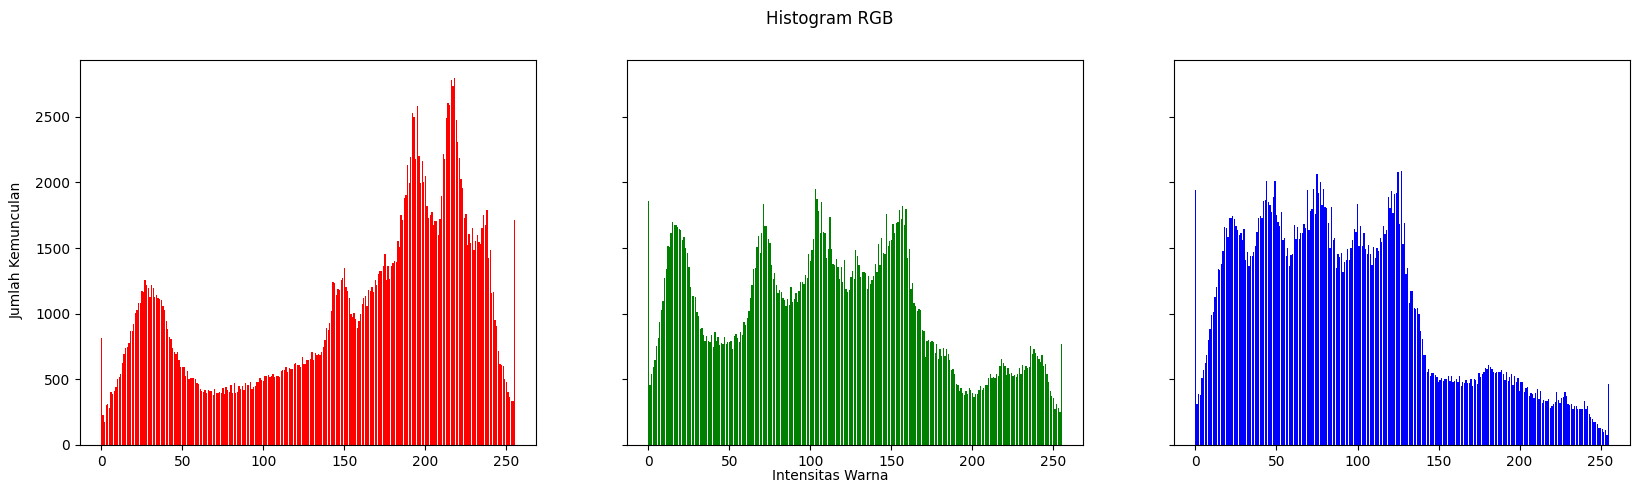

In [ ]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/Pertemuan 5/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

PRAKTIKUM D1

Apakah output histogram manual dan NumPy sama? True


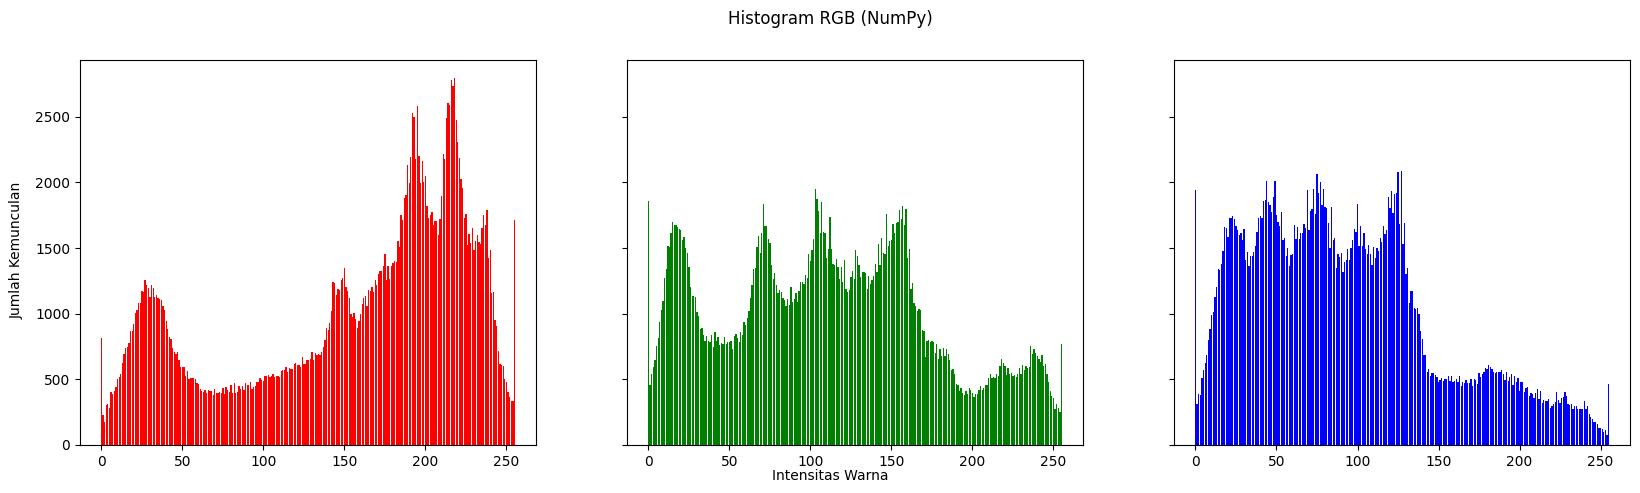

In [8]:
# Membuat histogram image menggunakan NumPy
red_np, bins_red = np.histogram(img[:,:,0].flatten(), bins=256, range=[0, 256])
green_np, bins_green = np.histogram(img[:,:,1].flatten(), bins=256, range=[0, 256])
blue_np, bins_blue = np.histogram(img[:,:,2].flatten().flatten(), bins=256, range=[0, 256])

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB (NumPy)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red_np, color='red')
axs[1].bar(names, green_np, color='green')
axs[2].bar(names, blue_np, color='blue')

# Membandingkan hasil
print("Apakah output histogram manual dan NumPy sama?", np.array_equal(red, red_np) and np.array_equal(green, green_np) and np.array_equal(blue, blue_np))

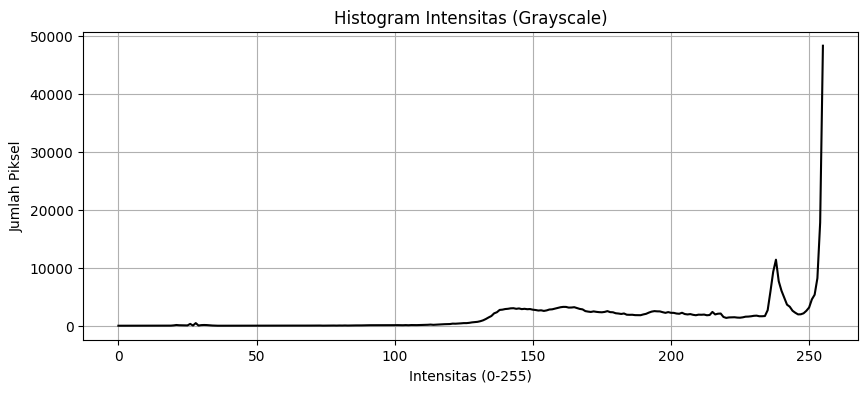

Rata-rata Intensitas: 203.25
Analisis: Gambar cenderung terang


In [11]:
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/Pertemuan 5/KTM lama.jpg')

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

hist = cv.calcHist([gray], [0], None, [256], [0, 256])

plt.figure(figsize=(10,4))
plt.plot(hist, color='black')
plt.title('Histogram Intensitas (Grayscale)')
plt.xlabel('Intensitas (0-255)')
plt.ylabel('Jumlah Piksel')
plt.grid()
plt.show()

mean_intensity = np.mean(gray)
print(f"Rata-rata Intensitas: {mean_intensity:.2f}")

if mean_intensity < 85:
    kondisi = "Gambar cenderung gelap"
elif mean_intensity < 170:
    kondisi = "Gambar memiliki intensitas sedang"
else:
    kondisi = "Gambar cenderung terang"

print("Analisis:", kondisi)
